# **ChurnMetrics EDA:**

#### Muhammad Abdullah - 516444
#### Ali Ahmad Khan - 502967

## **Loading and previewing the dataset**

In [ ]:
import pandas as pd

df = pd.read_csv('IBM_telco_churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **Checking general details like shape, dtypes and missing values**

In [ ]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())



Shape: (7043, 21)

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract          

## **Observation: *TotalCharges* should be float and *SeniorCitizen* should be treated as categorical**

## **Checking number of unique values and printing every unique value for each column**

In [ ]:
for col in df.columns:
    print(col, ":", df[col].nunique())

customerID : 7043
gender : 2
SeniorCitizen : 2
Partner : 2
Dependents : 2
tenure : 73
PhoneService : 2
MultipleLines : 3
InternetService : 3
OnlineSecurity : 3
OnlineBackup : 3
DeviceProtection : 3
TechSupport : 3
StreamingTV : 3
StreamingMovies : 3
Contract : 3
PaperlessBilling : 2
PaymentMethod : 4
MonthlyCharges : 1585
TotalCharges : 6531
Churn : 2


In [ ]:
import pandas as pd
from pprint import pprint

cols = df.columns[df.nunique() <= 5]

result = {col: df[col].unique().tolist() for col in cols}

pprint(result)


{'Churn': ['No', 'Yes'],
 'Contract': ['Month-to-month', 'One year', 'Two year'],
 'Dependents': ['No', 'Yes'],
 'DeviceProtection': ['No', 'Yes', 'No internet service'],
 'InternetService': ['DSL', 'Fiber optic', 'No'],
 'MultipleLines': ['No phone service', 'No', 'Yes'],
 'OnlineBackup': ['Yes', 'No', 'No internet service'],
 'OnlineSecurity': ['No', 'Yes', 'No internet service'],
 'PaperlessBilling': ['Yes', 'No'],
 'Partner': ['Yes', 'No'],
 'PaymentMethod': ['Electronic check',
                   'Mailed check',
                   'Bank transfer (automatic)',
                   'Credit card (automatic)'],
 'PhoneService': ['No', 'Yes'],
 'SeniorCitizen': [0, 1],
 'StreamingMovies': ['No', 'Yes', 'No internet service'],
 'StreamingTV': ['No', 'Yes', 'No internet service'],
 'TechSupport': ['No', 'Yes', 'No internet service'],
 'gender': ['Female', 'Male']}


## **Observation yet: Related Columns**

*   If 'InternetService'='No', then 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTV', 'TechSupport'='No internet Service'
*   If 'PhoneService'='No', then 'MultipleLines'='No phone service'



## **Checking target variable distribution**

In [ ]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


## **Performing a transformation to drop faulty rows in *TotalCharges* and then convert it to numeric for further analysis**

#### **NOTE:** This step is only for further analysis. In actual preprocessing these rows will be replaced by median filling

In [ ]:
converted = pd.to_numeric(df["TotalCharges"], errors="coerce")
invalid_rows = df[converted.isna() & df["TotalCharges"].notna()]
print(invalid_rows)


      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  ... 

In [ ]:
# Converting blank spaces in totalCharges column into NA and converting the column to numerical
import pandas as pd
df["TotalCharges"] = df["TotalCharges"].str.strip()
df["TotalCharges"] = df["TotalCharges"].replace("", pd.NA)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


In [ ]:
# Verifying conversion
print(df["TotalCharges"].dtype)
print(df["TotalCharges"].isna().sum())

float64
11


In [ ]:
# Droppping NA rows for reduced effect on further analysis
df = df.dropna(subset=["TotalCharges"])

In [ ]:
print(df.describe())


       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7032.000000  7032.000000     7032.000000   7032.000000
mean        0.162400    32.421786       64.798208   2283.300441
std         0.368844    24.545260       30.085974   2266.771362
min         0.000000     1.000000       18.250000     18.800000
25%         0.000000     9.000000       35.587500    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.862500   3794.737500
max         1.000000    72.000000      118.750000   8684.800000


## **Now correlating those columns with *'churn'* that seem logically most related to it**

#### Rationally, one would deduce that, a client with a longer commitment (period) to the company - *'yearly subscription'*, would be less inclined to churn the company


In [ ]:
ct = pd.crosstab(df["Contract"], df["Churn"], normalize="index")
print(ct)

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887228  0.112772
Two year        0.971513  0.028487


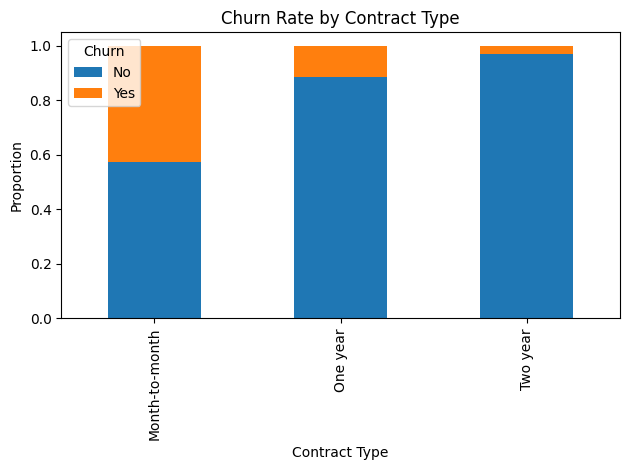

In [ ]:
# Plotting

import matplotlib.pyplot as plt

ct.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.xlabel("Contract Type")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

#### One can also think that the greater the number of months that a customer has stayed with the company - *'tenure'*, the lesser the chances might be of him churning the company

In [ ]:
# Finding min max tenure for making categorical groups for crosstab
print("Min tenure:", df["tenure"].min())
print("Max tenure:", df["tenure"].max())

Min tenure: 1
Max tenure: 72


In [ ]:
# Making groups based on min max values
bins = [0, 12, 24, 48, 72]
labels = ["0-12", "13-24", "25-48", "49-72"]

df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels, right=True)


In [ ]:
ct = pd.crosstab(df["tenure_group"], df["Churn"], normalize="index")
print(ct)

Churn               No       Yes
tenure_group                    
0-12          0.523218  0.476782
13-24         0.712891  0.287109
25-48         0.796110  0.203890
49-72         0.904868  0.095132


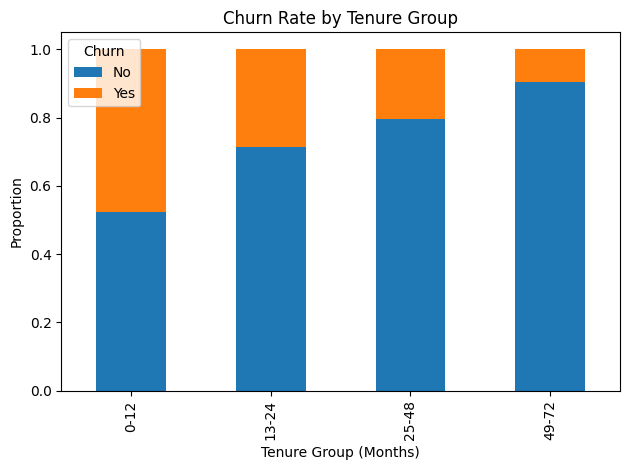

In [ ]:
ct = pd.crosstab(df["tenure_group"], df["Churn"], normalize="index")

ct.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Proportion")
plt.xlabel("Tenure Group (Months)")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()